In [112]:
# importting Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

#Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

#Evaluation metrics
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [113]:
df=pd.read_csv("/content/drive/MyDrive/Data Science/Dataset/usedCars (1).csv")

# Eda And Preprocessing


In [114]:
df.head()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


shows the first five rows of the dataset to understand its structure and sample data.

In [115]:
df.tail()

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
1059,588906,HYUNDAI,ELITE I20(2020-2020),ASTA O 1.2 BS VI,PETROL,White,42918,HATCHBACK,NaN,2020-09-01,2020,NaN,7.15 Lakhs,1st Owner,Rajasthan,K.S. Motors,Jaipur,1,8.3
1060,588945,HYUNDAI,XCENT(2017-2020),S,PETROL,White,78910,SEDAN,NaN,2019-01-01,2019,NaN,5.00 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,7.8
1061,588946,MAHINDRA,SCORPIO(2009-2014),VLX 2WD BS-III,DIESEL,White,76000,SUV,NaN,2013-05-01,2013,NaN,5.75 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,6.8
1062,588949,MARUTI SUZUKI,VITARA BREZZA,VDI,DIESEL,Silver,80120,HATCHBACK,NaN,2018-06-01,2018,NaN,7.71 Lakhs,1st Owner,Rajasthan,Rajasthan Car World,Jaipur,0,7.4
1063,588950,HONDA,CITY,SV MT DIESEL,DIESEL,Urban Titanium,77500,SEDAN,Manual,2014-01-01,2014,NaN,4.99 Lakhs,2nd Owner,Rajasthan,Rajasthan Car World,Jaipur,0,6.8


shows the last five rows of the dataset to understand the ending records and data consistency.

In [116]:
df.shape

(1064, 19)

shows the number of rows and columns present in the dataset.

In [117]:
df.dtypes


,0
Id,int64
Company,object
Model,object
Variant,object
FuelType,object
Colour,object
Kilometer,int64
BodyStyle,object
TransmissionType,object
ManufactureDate,object


displays the data types of all columns in the dataset.

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


provides a summary of the dataset, including column names, data types, and missing values.

In [119]:
df.nunique()

,0
Id,1064
Company,23
Model,218
Variant,575
FuelType,5
Colour,76
Kilometer,1006
BodyStyle,10
TransmissionType,9
ManufactureDate,162


shows the number of unique values present in each column of the dataset.

In [120]:
df.describe()

,Id,Kilometer,ModelYear,Warranty,QualityScore
count,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000
mean,568156.542293,52807.187970,2016.864662,0.738722,7.770207
std,16438.139974,33840.296979,2.996786,0.439538,0.719717
min,525978.000000,101.000000,2003.000000,0.000000,0.000000
25%,555321.500000,32113.500000,2015.000000,0.000000,7.500000
50%,572753.000000,49432.000000,2017.000000,1.000000,7.800000
75%,583072.750000,68828.500000,2019.000000,1.000000,8.100000
max,589122.000000,640000.000000,2023.000000,1.000000,9.400000


provides statistical summary of numerical columns, such as mean, minimum, maximum, and standard deviation.

In [121]:
df.isnull().sum()

,0
Id,0
Company,0
Model,0
Variant,0
FuelType,1
Colour,0
Kilometer,0
BodyStyle,0
TransmissionType,714
ManufactureDate,0


shows the total number of missing values present in each column of the dataset.

In [122]:
df.duplicated().sum()

np.int64(0)

In [123]:
#convert price column to numeric
def convert_price(price):

    price = str(price).replace(',', '').strip()

    if 'Lakhs' in price or 'Lakh' in price:
        number = float(
            price.replace('Lakhs', '')
                 .replace('Lakh', '')
                 .strip()
        )
        return number * 100000

    else:
        return float(price)

# Apply conversion
df['Price'] = df['Price'].apply(convert_price)

# Remove missing values if any
df.dropna(subset=['Price'], inplace=True)

This code converts the Price column into a proper numeric format by handling values in lakhs and removing unwanted characters for accurate model training.

In [124]:
print(df['Price'].head())
print(df['Price'].describe())

0    575000.0
1    435000.0
2    470000.0
3    990000.0
4    270000.0
Name: Price, dtype: float64
count    1.064000e+03
mean     8.350536e+05
std      5.726538e+05
min      9.500000e+04
25%      4.850000e+05
50%      6.750000e+05
75%      9.850000e+05
max      8.500000e+06
Name: Price, dtype: float64


displays the first few values of the cleaned Price column, while describe() provides its statistical summary.

In [125]:
#convert manufacture date to datetime
df['ManufactureDate']=pd.to_datetime(df['ManufactureDate'])
print(df['ManufactureDate'].head())

0   2018-02-01
1   2021-03-01
2   2015-03-01
3   2020-08-01
4   2010-11-01
Name: ManufactureDate, dtype: datetime64[ns]


This code converts the ManufactureDate column into datetime format for easier date-based analysis and feature extraction.

In [126]:
#create car Age feature
current_year=2026
df['CarAge']=current_year-df['ModelYear']
print(df[['ModelYear','CarAge']].head())

   ModelYear  CarAge
0       2018       8
1       2021       5
2       2015      11
3       2020       6
4       2010      16


This code creates a new feature called CarAge by calculating the age of each car from its manufacturing year.

In [127]:
#drop unnecessary columns
df.drop(columns=['Id','ManufactureDate'],inplace=True)

This code removes unnecessary columns that are not useful for model training and prediction.

In [128]:
#save cleaned data
df.to_csv("Usedcars_cleaned_data.csv",index=False)

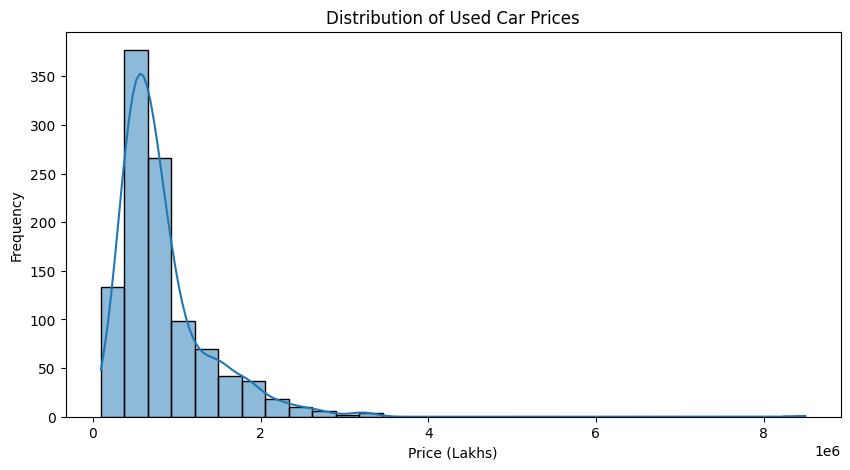

In [129]:
#Distribution of car prices
plt.figure(figsize=(10,5))
sns.histplot(df['Price'],bins=30,kde=True)

plt.title("Distribution of Used Car Prices")
plt.xlabel('Price (Lakhs)')
plt.ylabel('Frequency')
plt.show()

This visualization shows the distribution of used car prices, helping identify common price ranges, skewness, and outliers in the dataset.



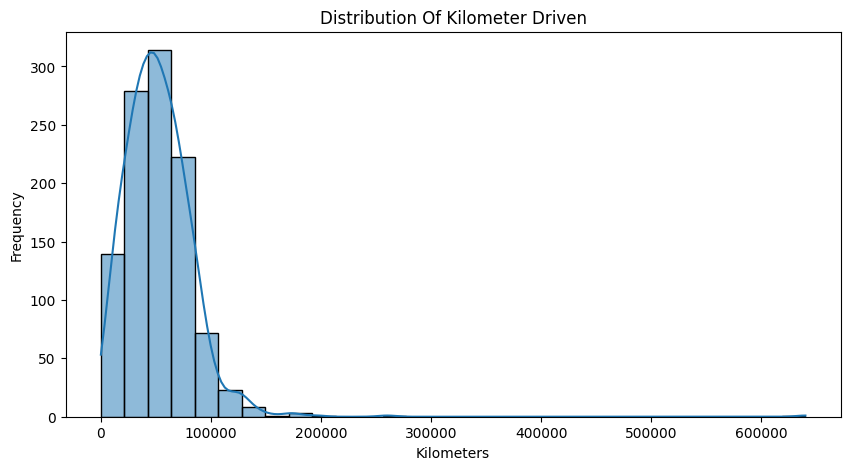

In [130]:
#Distribution of kilometer driven
plt.figure(figsize=(10,5))
sns.histplot(df['Kilometer'],bins=30,kde=True)

plt.title('Distribution Of Kilometer Driven')
plt.xlabel('Kilometers')
plt.ylabel('Frequency')
plt.show()



*   Most used cars have moderate mileage.
*   Mileage may negatively impact price.



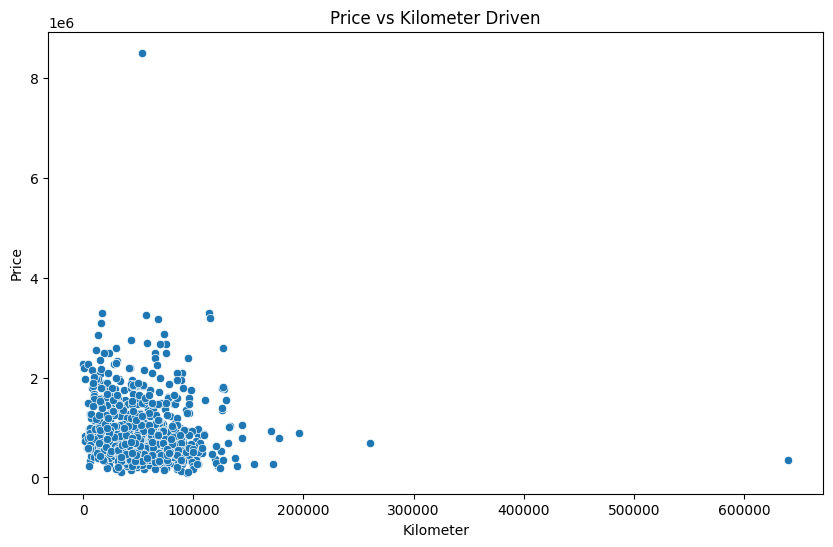

In [131]:
#Price vs Kilometer
plt.figure(figsize=(10,6))
sns.scatterplot(x='Kilometer', y='Price',data=df)

plt.title('Price vs Kilometer Driven')
plt.xlabel('Kilometer')
plt.ylabel('Price')
plt.show()



*   As Kilometers increase, car price generally decreases.
*   High mileage cars usually have lower resale value.




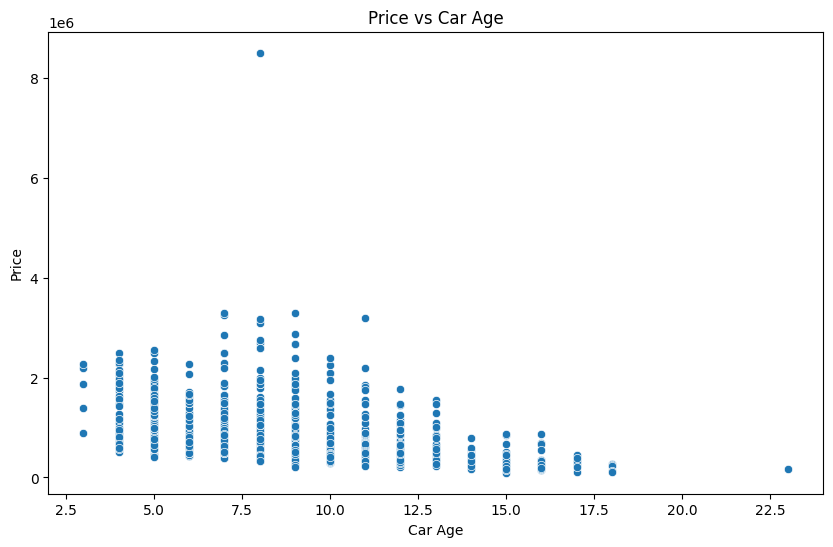

In [132]:
#Price vs Car Age
plt.figure(figsize=(10,6))
sns.scatterplot(x='CarAge', y='Price',data=df)
plt.title('Price vs Car Age')
plt.xlabel('Car Age')
plt.ylabel('Price')
plt.show()



*   Newer cars tend to have higher prices.
*   Older cars show lower resale value due to depreciation.



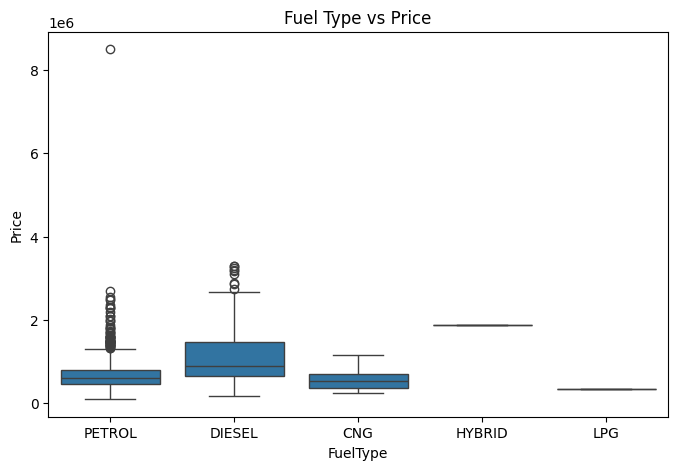

In [133]:
# Fuel Type Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='FuelType',y='Price',data=df)

plt.title('Fuel Type vs Price')
plt.show()



*   Diesel vehicles may show higher resale values.
*   Petrol vehicles dominate the dataset.



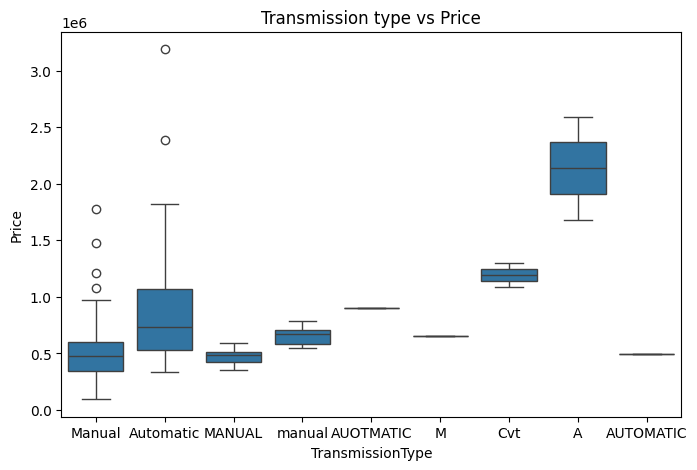

In [134]:
#Transmission Type Analysis
plt.figure(figsize=(8,5))
sns.boxplot(x='TransmissionType',y='Price',data=df)

plt.title('Transmission type vs Price')
plt.show()



*   Automatic transmission cars are often priced higher.
*   Manual transmission cars are more common.



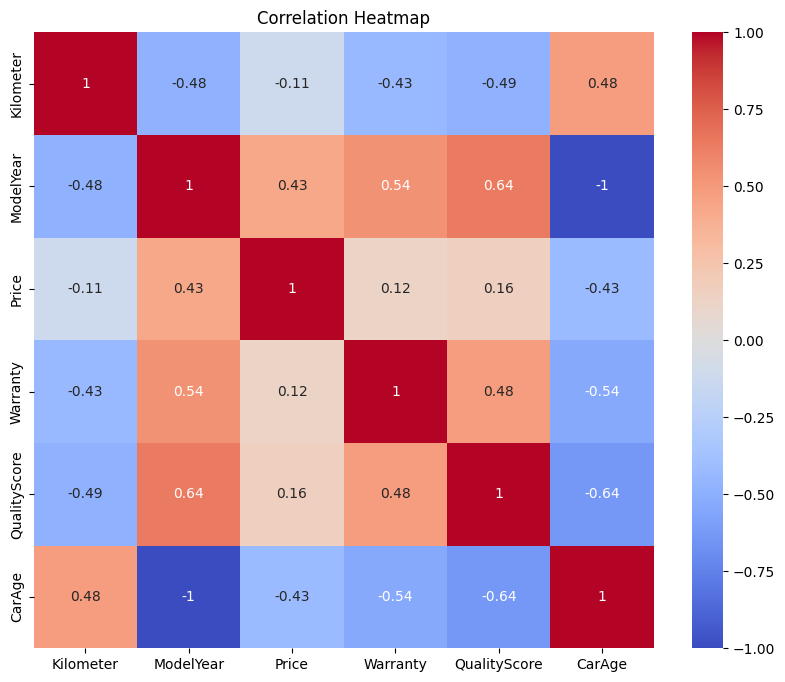

In [135]:
#Correlation Heatmap
numeric_df=df.select_dtypes(include=np.number)
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

This heatmap shows the correlation between numerical features, helping identify variables that strongly influence car prices.

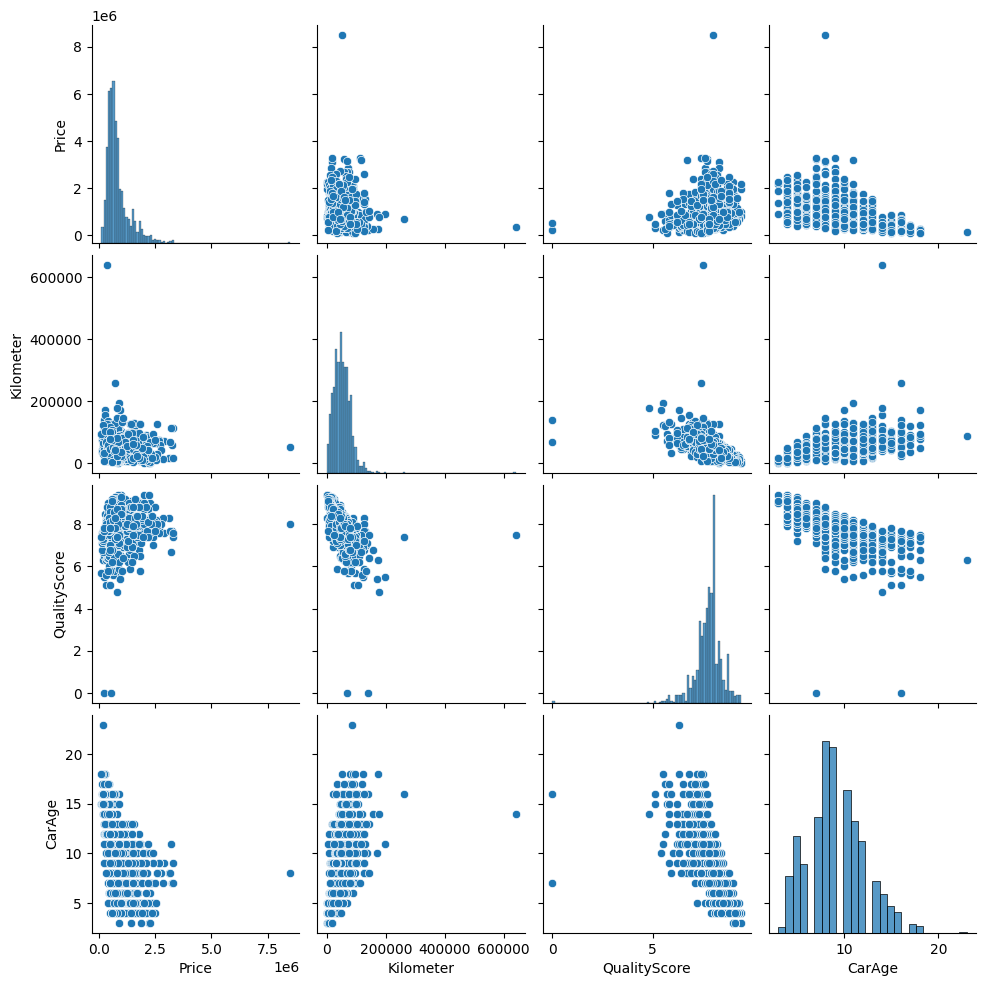

In [136]:
#pairplot
sns.pairplot(
    df[['Price','Kilometer','QualityScore','CarAge']]
)
plt.show()

Pairplot helps to identity linear relationships, clusters, outliers, feature interactions, etc.

In [137]:
#prepare data for Modelling
X=df.drop('Price',axis=1)
y=df['Price']

separates the dataset into input features (X) and the target variable (y) for machine learning model training.

In [138]:
X.columns.tolist()

['Company',
 'Model',
 'Variant',
 'FuelType',
 'Colour',
 'Kilometer',
 'BodyStyle',
 'TransmissionType',
 'ModelYear',
 'CngKit',
 'Owner',
 'DealerState',
 'DealerName',
 'City',
 'Warranty',
 'QualityScore',
 'CarAge']

In [139]:
#identify numeric and categorical columns
numeric_features=X.select_dtypes(include=['int64','float64']).columns
categorical_features=X.select_dtypes(include=['object']).columns

print('Numeric Features:\n',numeric_features)
print('\nCategorical Features:\n', categorical_features)

Numeric Features:
 Index(['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge'], dtype='object')

Categorical Features:
 Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'DealerName',
       'City'],
      dtype='object')


This step identifies numerical and categorical features, allowing appropriate preprocessing techniques to be applied to each data type.

In [140]:
#Data preprocessing Pipeline
numeric_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('Scaler',StandardScaler())
])

categorical_transformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer(
    transformers=[
        ('num',numeric_transformer,numeric_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

This preprocessing pipeline handles missing values, scales numerical features, and encodes categorical variables to prepare the data for machine learning models.

In [141]:
# removing outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower) & (df['Price'] <= upper)]

removes price outliers using the IQR method to improve model accuracy and reduce the impact of extreme values.

In [142]:
#train-test-split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(851, 17)
(213, 17)


splits the dataset into training and testing sets to train the model and evaluate its performance on unseen data.

# Model Training


1.   Linear Regression
2.   Decision Tree regressor


1.   Random Forest Regressor




# Linear Regression

In [143]:
linear_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',LinearRegression())
])

linear_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'DealerName',
       'City'],
      dtype='object'))])),
                ('model', LinearRegression())])

#Decision Tree regressor

In [144]:
decision_tree_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',DecisionTreeRegressor(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

decision_tree_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'DealerName',
       'City'],
      dtype='object'))])),
                ('model',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

# Random Forest Regressor

In [145]:
random_forest_model=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ))
])

random_forest_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('Scaler',
                                                                   StandardScaler())]),
                                                  Index(['Kilometer', 'ModelYear', 'Warranty', 'QualityScore', 'CarAge'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Company', 'Model', 'Variant', 'FuelType', 'Colour', 'BodyStyle',
       'TransmissionType', 'CngKit', 'Owner', 'DealerState', 'DealerName',
       'City'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(max_depth=15, min_samples_leaf=2,
                                       min_samples_split=5, n_estimators=300,
                                       random_state=42))])

# Model evaluation

In [146]:
def evaluate_model(model, X_test, y_test, model_name):
  y_pred=model.predict(X_test)

  mse=mean_squared_error(y_test,y_pred)
  mae=mean_absolute_error(y_test,y_pred)
  r2=r2_score(y_test,y_pred)

  print(f'\n{model_name}')
  print('-'*40)
  print(f'MSE : {mse:.4f}')
  print(f'MAE : {mae:.4f}')
  print(f'R2 Score :{r2:.4f}')

  return y_pred, mse, mae, r2

In [147]:
# Evaluate linear regression
linear_pred, linear_mse, linear_mae, linear_r2=evaluate_model(
    linear_model,
    X_test,
    y_test,
    'Linear Regression'
)


Linear Regression
----------------------------------------
MSE : 153207809666.7446
MAE : 223484.5759
R2 Score :0.3596


In [148]:
#Evaluate Decision Tree
dt_pred, dt_mse, dt_mae, dt_r2=evaluate_model(
    decision_tree_model,
    X_test,
    y_test,
    'Decision Tree regressor'
)


Decision Tree regressor
----------------------------------------
MSE : 114805054819.1928
MAE : 229781.0166
R2 Score :0.5201


In [149]:
# Evaluate Random Forest
rf_pred, rf_mse, rf_mae, rf_r2=evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    'Random Forest Regressor'
)


Random Forest Regressor
----------------------------------------
MSE : 83859309736.6928
MAE : 161366.9462
R2 Score :0.6495


# Compare Model Performance

In [150]:
comparision_df=pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MSE':[linear_mse,dt_mse,rf_mse],
    'MAE':[linear_mae,dt_mae,rf_mae],
    'R2 Score':[linear_r2,dt_r2,rf_r2]
})
print(comparision_df)

               Model           MSE            MAE  R2 Score
0  Linear Regression  1.532078e+11  223484.575905  0.359614
1      Decision Tree  1.148051e+11  229781.016575  0.520132
2      Random Forest  8.385931e+10  161366.946240  0.649481


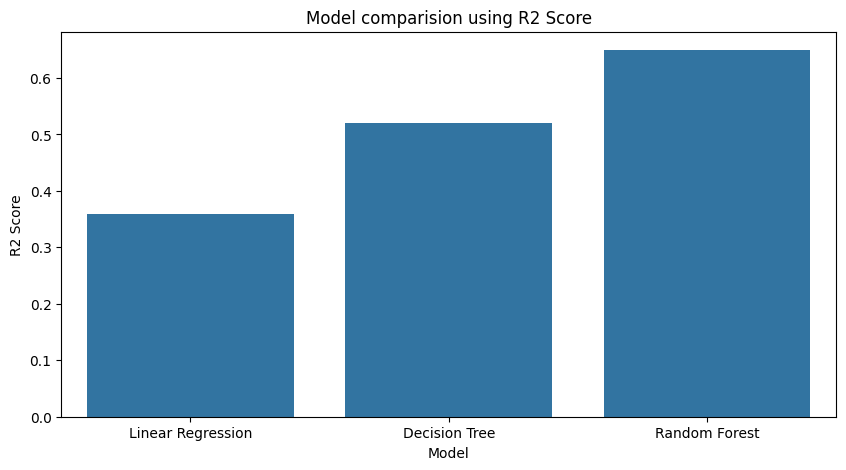

In [151]:
#visual comparision of models
plt.figure(figsize=(10,5))
sns.barplot(x='Model',y='R2 Score',data=comparision_df)

plt.title('Model comparision using R2 Score')
plt.ylabel('R2 Score')
plt.show()



*   Higher R2 score indicates better predictive performance.


*   Lower MSE and MAE indicate fewer prediction errors.


*   Random Forest generally performs best because it captures nonlinear relationships.



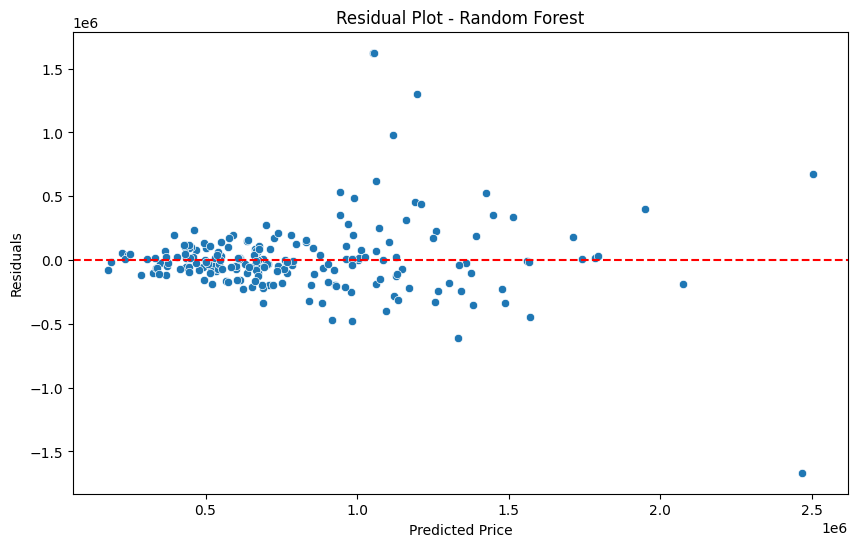

In [152]:
#Residual Erro Analysis

#residualplot for Random Forest
residuals=y_test - rf_pred
plt.figure(figsize=(10,6))
sns.scatterplot(x=rf_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot - Random Forest')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.show()



*   Residuals should be randomly distributed around zero.
*   Patterns may indicate underfitting or overfitting.


*   Random Forest usually produces more stable residual distribution.





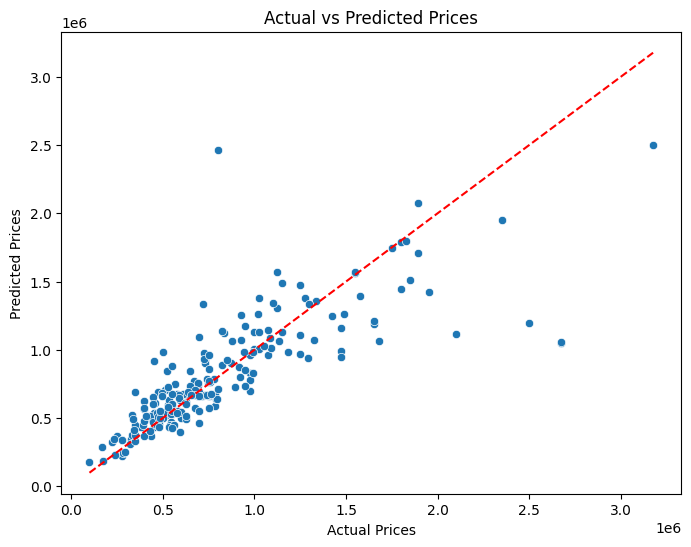

In [153]:
# Actual vs Predicted Prices
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()



*   Points close to the diagonal line indicate accurate predictions.
*   Large deviations indicate prediction errors.



In [154]:
import joblib

joblib.dump(random_forest_model, "car_price_model.pkl")

['car_price_model.pkl']

# Feature Importance Analysis

In [155]:
## Extract trained Random Forest model
rf_model= random_forest_model.named_steps['model']

#get feature names after encoding
encoded_features=random_forest_model.named_steps[
    'preprocessor'
].get_feature_names_out()

#feature importance
importance_df=pd.DataFrame({
    'Feature':encoded_features,
    'Importance':rf_model.feature_importances_
})

#sort values
importance_df=importance_df.sort_values(
    by='Importance',
    ascending=False
)

#Top 15 Important features
print(importance_df.head(15))

                        Feature  Importance
799    cat__BodyStyle_HATCHBACK    0.199993
1                num__ModelYear    0.094455
4                   num__CarAge    0.085424
804          cat__BodyStyle_SUV    0.068482
0                num__Kilometer    0.052790
610       cat__Variant_V PETROL    0.049569
108         cat__Model_FORTUNER    0.042267
18   cat__Company_MERCEDES BENZ    0.035722
803        cat__BodyStyle_SEDAN    0.026443
70   cat__Model_CITY(2017-2020)    0.025009
133    cat__Model_INNOVA CRYSTA    0.021666
25          cat__Company_TOYOTA    0.021570
97         cat__Model_ENDEAVOUR    0.018270
724        cat__FuelType_DIESEL    0.017427
3             num__QualityScore    0.017084


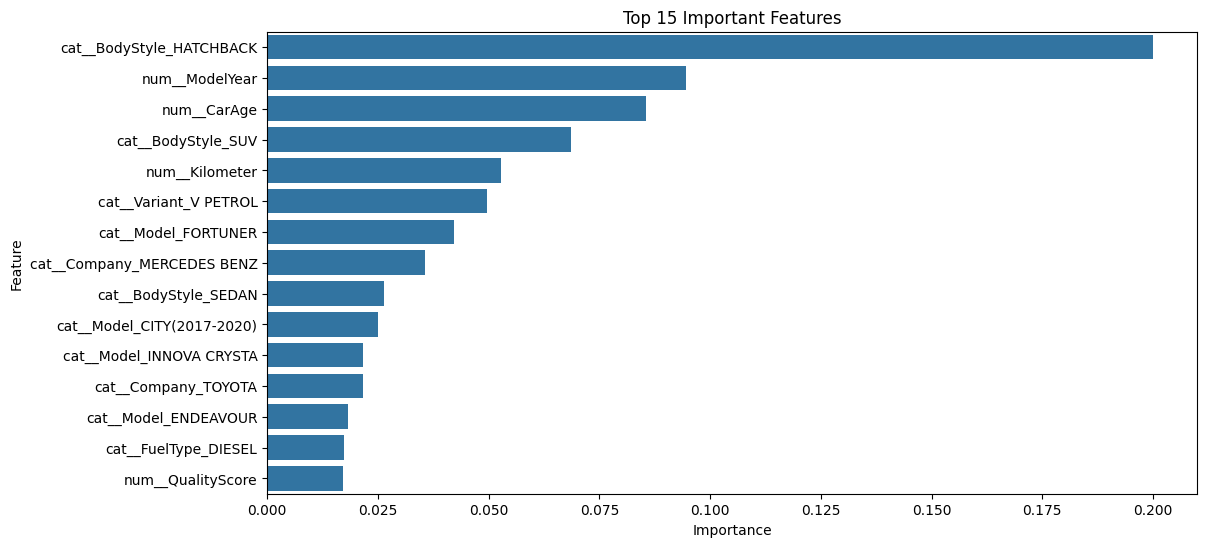

In [156]:
#visualize feature importance
plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(15)
)

plt.title('Top 15 Important Features')
plt.show()



*   Most influential features are typically:
CarAge,Kilometer,QualityScore,TransmissionType,FuelType and Company.
These variables strongly affect resale value.




# Conclusion


This project successfully developed a machine learning system for predicting used car prices using various vehicle-related features. The workflow included data preprocessing, exploratory data analysis, feature engineering, model training, and evaluation. Among the implemented models, the Random Forest Regressor achieved the best performance with the highest R² score, demonstrating its effectiveness in handling complex and nonlinear data patterns. The project highlights the practical application of machine learning techniques in real-world price prediction problems and provides valuable insights into factors influencing used car prices.